# 04 — Explicabilidade e análise de erros

Análises descritivas posteriores ao teste, sem reajustar modelos com D2.

In [1]:
from pathlib import Path
import os
import sys
raiz = Path.cwd()
if not (raiz / 'analisar_dados_drift.py').exists():
    raiz = raiz.parent
assert (raiz / 'analisar_dados_drift.py').exists(), 'Abra o notebook dentro do repositorio.'
os.chdir(raiz)
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))
import pandas as pd
import json
from IPython.display import display, Markdown, Image

from analisar_resultados_finais import conferir_execucao
final = Path('resultados/final')
analises = Path('resultados/analises_finais')
pronto = (final / 'manifesto_resultados.json').exists()
if pronto:
    protocolo = conferir_execucao(final)
else:
    display(Markdown('**Pendente:** revisar e congelar o protocolo, depois executar o experimento final. Este notebook não treina modelos nem abre D2.'))
analises_prontas = pronto and (analises / 'manifesto_analises.json').exists()
if analises_prontas:
    from protocolo_final import sha256
    manifesto = json.loads((analises / 'manifesto_analises.json').read_text(encoding='utf-8'))
    assert manifesto['resultados_sha256'] == sha256(final / 'manifesto_resultados.json')
    assert manifesto['protocolo_sha256'] == sha256(final / 'protocolo_congelado.json')
    for nome, digest in manifesto['arquivos'].items():
        caminho = (analises / nome).resolve()
        assert caminho.is_relative_to(analises.resolve()) and sha256(caminho) == digest
elif pronto:
    display(Markdown('**Pendente:** executar analisar_resultados_finais.py para gerar as análises.'))


## Importância por permutação

Embaralhamos um atributo e medimos a queda de MCC, com o modelo já treinado. Valores negativos são preservados. Correlação entre atributos pode esconder ou dividir importância; a medida não demonstra causalidade. As repetições de permutação e as sementes de treinamento têm desvios separados.

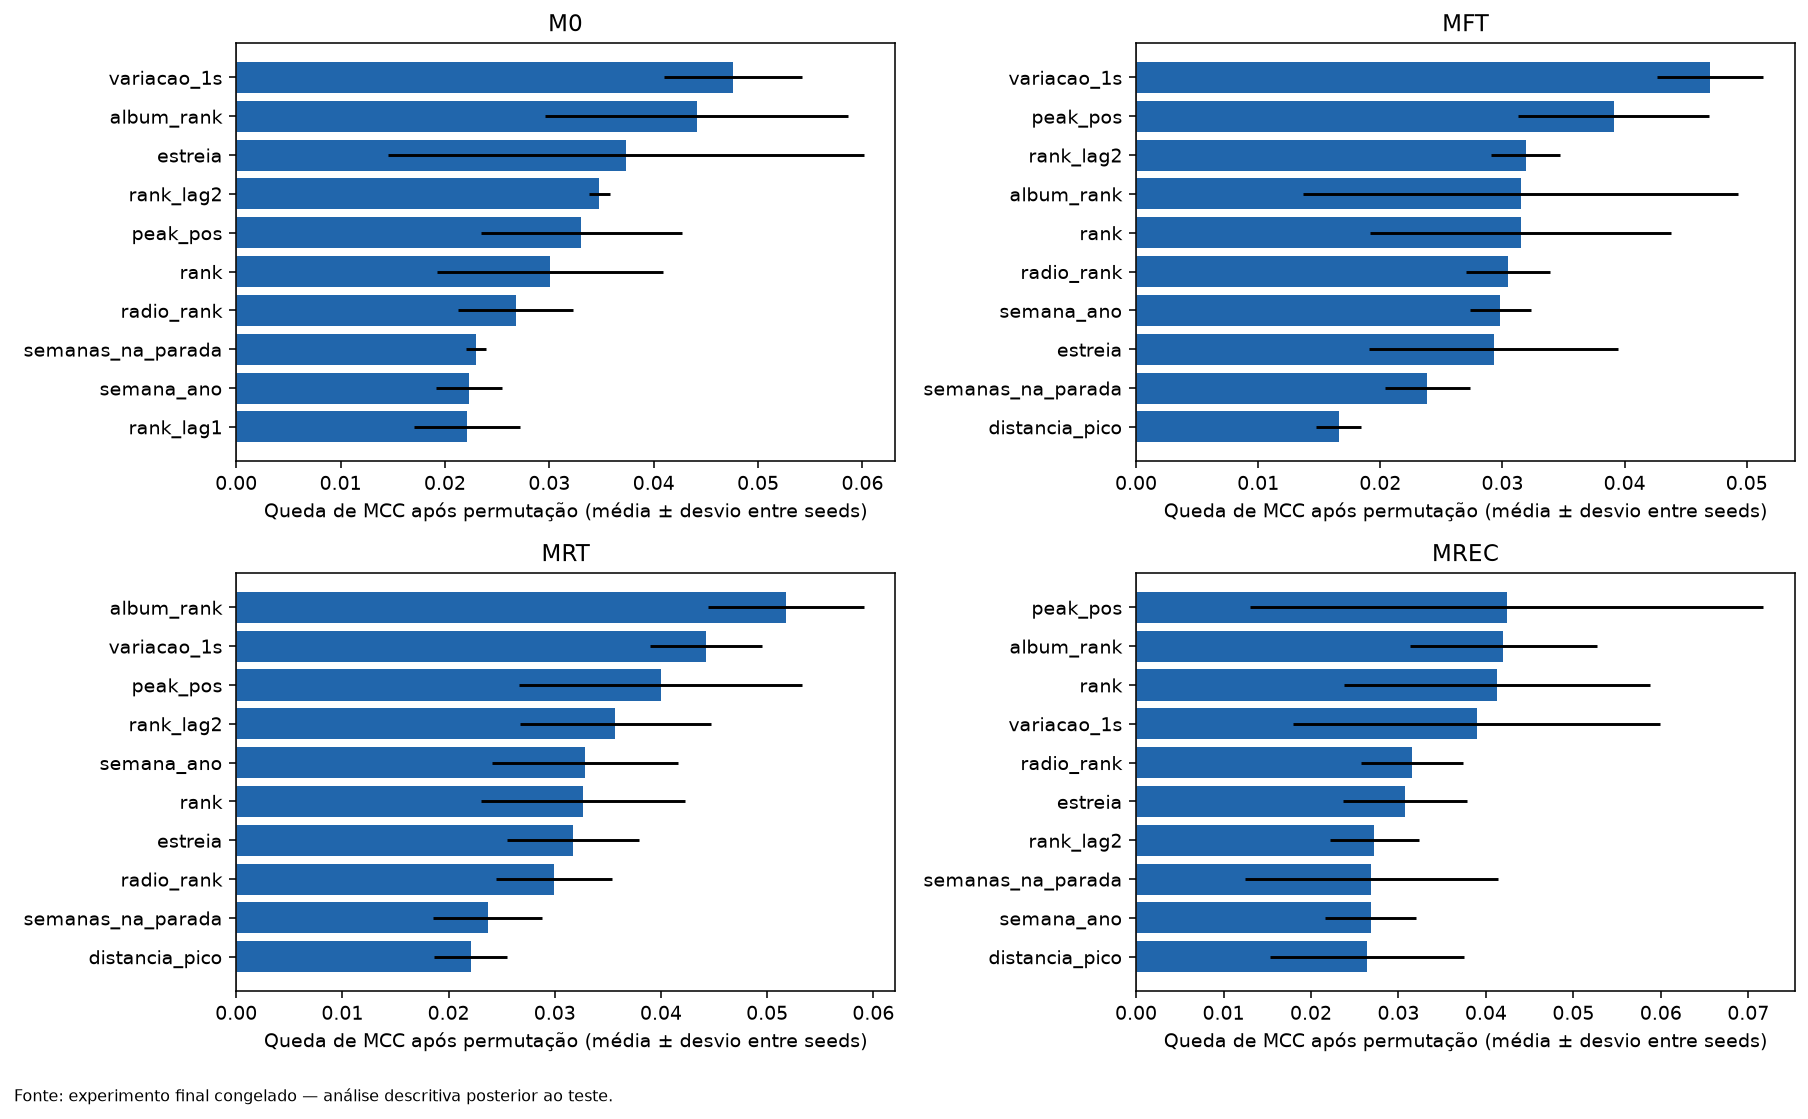

,modelo,atributo,importancia_media,desvio_seeds
0,M0,album_presente,0.015716,0.007371
1,M0,album_rank,0.044108,0.014522
2,M0,digital_presente,0.003400,0.001200
3,M0,digital_rank,0.011396,0.002415
4,M0,distancia_pico,0.018171,0.004344
...,...,...,...,...
75,MRT,semana_ano,0.032868,0.008769
76,MRT,semanas_na_parada,0.023674,0.005145
77,MRT,streaming_presente,0.007851,0.004078
78,MRT,streaming_rank,0.013372,0.007844


In [2]:
if analises_prontas:
    display(Image(filename=str(analises/'importancias.png')))
    display(pd.read_csv(analises/'importancias_resumo.csv'))

## Matrizes e erros por grupo

Falso positivo: previu melhora que não ocorreu. Falso negativo: não previu uma melhora. As matrizes mostram a média das contagens entre sementes. Os grupos foram definidos no protocolo: posição, tempo na parada, trimestre e indicadores de presença. Observe o tamanho de cada grupo antes de comparar métricas.

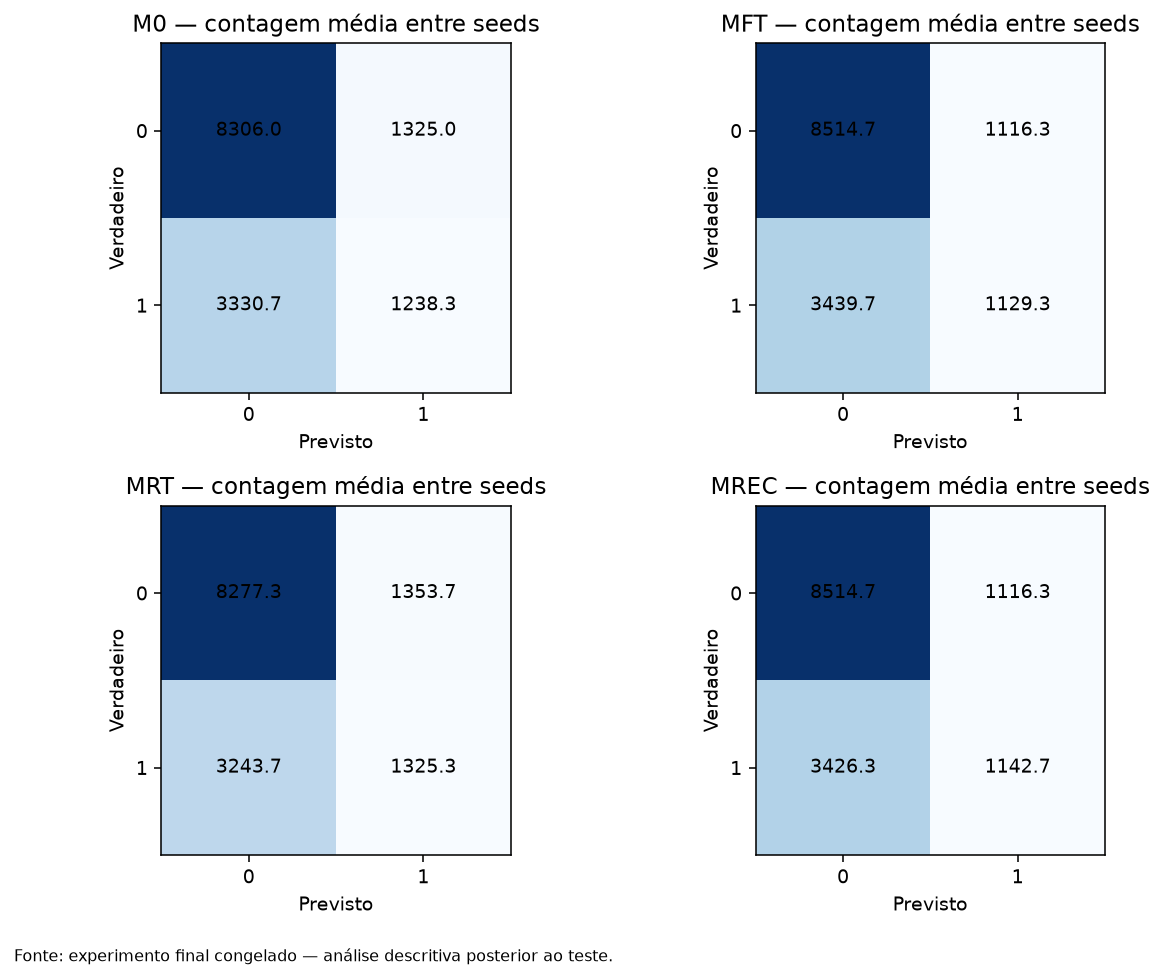

,modelo,seed,corte,grupo,n,positivos,mcc,f1,precision,recall,pr_auc,roc_auc,accuracy,tn,fp,fn,tp
0,GB,42,faixa_rank,1-10,1420,301,0.175920,0.264501,0.438462,0.189369,0.362660,0.688897,0.776761,1046,73,244,57
1,GB,42,faixa_rank,11-40,4260,1341,0.201011,0.428920,0.471008,0.393736,0.472770,0.667231,0.669953,2326,593,813,528
2,GB,42,faixa_rank,41-100,8520,2927,0.181650,0.479474,0.451798,0.510762,0.475493,0.644994,0.619014,3779,1814,1432,1495
3,GB,42,tempo_parada,1-4,4922,1261,0.378724,0.559644,0.447131,0.747819,0.478846,0.770826,0.698497,2495,1166,318,943
4,GB,42,tempo_parada,5-12,4072,1537,0.146571,0.504173,0.452012,0.569941,0.471851,0.614577,0.576866,1473,1062,661,876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,MRT,2024,streaming_presente,1,5968,1686,0.198140,0.288588,0.549085,0.195730,0.463343,0.701047,0.727379,4011,271,1356,330
476,MRT,2024,digital_presente,0,11735,3843,0.179170,0.353102,0.511605,0.269581,0.462958,0.660912,0.676523,6903,989,2807,1036
477,MRT,2024,digital_presente,1,2465,726,0.191637,0.376139,0.471933,0.312672,0.457706,0.673528,0.694523,1485,254,499,227
478,MRT,2024,album_presente,0,5870,2062,0.158161,0.401020,0.481961,0.343356,0.462171,0.630453,0.639693,3047,761,1354,708


In [3]:
if analises_prontas:
    display(Image(filename=str(analises/'matrizes_confusao.png')))
    display(pd.read_csv(analises/'erros_grupos.csv'))

## Exemplos e interpretação

A tabela contém os erros de maior confiança de cada tipo/modelo/semente, com os atributos utilizados. Esses exemplos ilustram falhas, não sua frequência total.

In [4]:
if analises_prontas:
    display(pd.read_csv(analises/'erros_exemplos.csv'))
    display(Markdown((analises/'RELATORIO.md').read_text(encoding='utf-8')))

,row_id,date,title,artist,alvo,modelo,seed,probabilidade,predicao,rank,...,radio_presente,streaming_rank,streaming_presente,digital_rank,digital_presente,album_rank,album_presente,mes,semana_ano,tipo_erro
0,1270,2024-03-13,Sensational,Chris Brown Featuring Davido & Lojay,0,GB,42,0.858479,1,71,...,1,51.0,0,51.0,0,201.0,0,3,11,FP
1,4395,2024-10-16,This Is My Dirt,Justin Moore,0,GB,42,0.851655,1,96,...,1,51.0,0,51.0,0,201.0,0,10,42,FP
2,1482,2024-03-27,Back Then Right Now,Tyler Hubbard,0,GB,42,0.849560,1,83,...,1,51.0,0,51.0,0,201.0,0,3,13,FP
3,14190,2026-09-02,Kid Myself,John Morgan,0,GB,42,0.849454,1,91,...,1,51.0,0,51.0,0,201.0,0,9,36,FP
4,11875,2026-03-25,Watching Us,Wale & Leon Thomas,0,GB,42,0.847080,1,76,...,1,51.0,0,51.0,0,201.0,0,3,13,FP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,5637,2025-01-15,DTMF,Bad Bunny,1,MRT,2024,0.016755,0,38,...,0,27.0,1,51.0,0,2.0,1,1,3,FN
316,901,2024-02-21,Texas Hold 'Em,Beyonce,1,MRT,2024,0.017315,0,2,...,0,4.0,1,1.0,1,100.0,1,2,8,FN
317,1504,2024-04-03,Too Sweet,Hozier,1,MRT,2024,0.018335,0,5,...,0,3.0,1,5.0,1,10.0,1,4,14,FN
318,609,2024-01-31,Redrum,21 Savage,1,MRT,2024,0.019049,0,10,...,0,3.0,1,51.0,0,1.0,1,1,5,FN


# E13–E15 — Análises após avaliação final

Melhor estratégia atualizada por MCC médio observado em D2: MRT.
Essa identificação é descritiva: todos os modelos foram avaliados antes e
nenhum é reajustado ou reavaliado com parâmetros escolhidos pelo resultado.

Drift usa as mesmas medidas de E11. Intervalos de PSI são definidos no período
de referência de cada comparação, incluindo D1 na comparação D1→D2. Alteração
do alvo não prova concept drift. Não são usados p-valores iid.

Importâncias foram calculadas para as quatro estratégias, em todas as seeds,
com 10 permutações e limiar 0.5.
Valores negativos são mantidos. Atributos correlacionados podem dividir ou
ocultar importância; permutação não mede causalidade. Desvios entre seeds
e entre repetições são registrados separadamente, sem interpretação como IC.

As matrizes mostram contagens médias entre seeds, não observações independentes
adicionais. Erros por grupo incluem tamanho da amostra; cortes pequenos exigem
cautela. As tabelas de exemplos contêm os falsos positivos e falsos negativos
mais confiantes de cada modelo/seed. D0 em m0_por_periodo.csv é desempenho de
treino, portanto não deve ser comparado a D1/D2 como se fosse teste independente.

Artefatos: drift.csv, intervalos_psi.csv, alvo_periodos.csv,
importancias_repeticoes.csv, importancias_seeds.csv, importancias_resumo.csv,
erros_grupos.csv, erros_exemplos.csv, m0_por_periodo.csv e três figuras.
